<style>
    /* we can use injections to style the resulting pdf */

    /* wrapping */
    pre, .jp-CodeCell .jp-Editor {
        display: block!important;
    }
    .jp-Cell-inputArea pre {
           page-break-inside: avoid !important;
    }
    .cm-editor.cm-s-jupyter .highlight pre {
        white-space: pre-wrap !important;
    }

    /* margins */
    div#notebook-container,
    div.container,
    div#notebook,
    .jp-Notebook {
        max-width: none !important;
        width: 102.6% !important;
        margin-left: -2.6% !important;
        padding: 0 !important;
    }
    .jp-MarkdownCell {
        margin-left: -6px;
        margin-bottom: 8px;
        margin-top: 12px;
    }
    .jp-OutputArea .jp-RenderedText {
        padding-left: calc(1ch + 16px);
        padding-top: 4px;
        padding-bottom: 8px;
    }
</style>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tqdm import tqdm
from joblib import Parallel, delayed
import re
import unicodedata
from lingua import Language, LanguageDetectorBuilder
from gensim.models import Word2Vec, Phrases
from gensim.models.phrases import Phraser
import gensim
import statsmodels.formula.api as smf

In [2]:
# final df versions from the qc (i.e. with body_normalized for comments)

In [3]:
comments_df = pd.read_parquet('comments_df.parquet')

In [4]:
submissions_df = pd.read_parquet('submissions_df.parquet')

In [5]:
author_stats_df = pd.read_parquet('author_stats_df.parquet')

In [6]:
# 1. LANGUAGE IDENTIFICATION

In [7]:
BATCH_SIZE = 10000
N_JOBS = -1

In [8]:
# we use a global variable for the worker process
_worker_detector = None

def get_worker_detector():
    global _worker_detector
    if _worker_detector is None:
        languages = [
            Language.ENGLISH, Language.FRENCH, Language.GERMAN, Language.SPANISH,
            Language.RUSSIAN, Language.UKRAINIAN, Language.POLISH, Language.CHINESE,
            Language.JAPANESE, Language.PORTUGUESE, Language.ITALIAN, Language.DUTCH,
            Language.INDONESIAN, Language.VIETNAMESE, Language.ARABIC, Language.PERSIAN,
            Language.TURKISH
        ]
        _worker_detector = LanguageDetectorBuilder.from_languages(*languages).build()
    return _worker_detector

We have identified certain issues with the current language identification approach, primarily concerning the identification of languages for submissions and the incorrect identification of languages for comments that are close to the length threshold. In the previous iteration, we used normalized text for comments and raw text for submissions. However, this proved to be too much of a simplification:

* Due to insufficient cleaning, many short submissions with less than 33 characters of organic human text, but with many technical markers in the selftext (formatting, poll markers, image links) are not being filtered out, which results in lingua assigning them the wrong language.
* For comments, even though we used a normalized version of the text, we did not remove token replacements (e.g., <URL> or <DATE>), which also introduced ambiguity into the process.

With the introduction of these changes, we decided to discard the “english_stopword” category - although manual verification at the previous stage did not reveal any significant problems with this approach, a fixed threshold for the number of intersections can lead to overconfidence in the case of long messages (for which we are confident in the results of lingua, considering the higher quality cleaning).

However, both the previous and current approaches are not particularly effective for short messages (bordering on the threshold in length). Although it guarantees a high degree of confidence that English labeled text was indeed English, it also leads to a large number of false negatives (English text labeled as non-English). For example, a large number of short English comments that mention ChatGPT fall into the nl category. Considering that high-emotion validation often happens in short bursts and roleplay negotiations are often quick, if we raise the threshold to 50+, we can potentially bias the dataset towards “intellectual/debate” posts and lose the “emotional/reactive” signal. At the same time:
* Since Reddit in general, and the communities we analyze in a narrow sense, are English-speaking, we can assume that the prior probability of a comment being English is quite high.
* The communities we analyze (SillyTavern, LocalLlama) use heavy jargon that confuses language detectors

With this in mind, we decided to implement a rescue step for the low_confidence and popular non-en categories, to which English comments are often mistakenly assigned (NL/DE/FR/ES/IT).

We also revised our approach toward the use of thresholds. Considering that submissions and comments are structurally different
(while a 33-character comment is a complete semantic unit, a 33-character submission (title + selftext combined) is often low-effort, spam, or a media-only post), we decided to use a higher standard for submissions and introduce a density check. We also added some additional popular languages (e.g., Polish), which also helped reduce the number of false assignments.

In [9]:
# the specific languages Lingua often confuses with short English text
RESCUE_TARGET_LANGS = {'nl', 'de', 'fr', 'es', 'it'}

# expanded list to differentiate English from NL/DE/FR/ES/IT
ENGLISH_RESCUE_WORDS = {
    # pronouns
    'the', 'this', 'that', 'these', 'those', 'with', 'from', 'about',
    'which', 'what', 'when', 'where', 'who', 'why', 'how',
    'your', 'their', 'our', 'his', 'her', 'its', 'my',

    # verbs
    'have', 'has', 'had', 'been', 'was', 'were', 'are',
    'will', 'would', 'could', 'should', 'can', 'do', 'does', 'did',
    'know', 'think', 'like', 'just', 'get', 'got', 'make', 'made',

    # conjunctions
    'not', 'but', 'and', 'because', 'while', 'since', 'very', 'really',

    # contractions
    "don't", "cant", "can't", "won't", "didn't", "wouldn't", "couldn't", "shouldn't",
    "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't",
    "i'm", "im", "you're", "we're", "they're", "he's", "she's", "it's", "that's",
    "ive", "i've", "youve", "weve"
}

In [10]:
def super_clean_text(text):
    if not isinstance(text, str): return ""

    # detailed cleaning based on normalize_comment from QC part + removal of token replacements
    # we perform this before normalization so as not to distort the text structure
    text = text.lower()
    text = re.sub(r'\[(.*?)\]\(.*?\)', '1', text) # links
    text = re.sub(r'https?://\S+', ' ', text)  # URLs
    text = re.sub(r'(?:(?:/)?u/)([A-Za-z0-9_.\-]+)\b', ' ', text) # usernames
    text = re.sub(r'(?:(?:/)?r/)([A-Za-z0-9_.\-]+)\b', ' ', text) # subreddits
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}(?:\s*UTC)?\b', ' ', text) # dates
    text = re.sub(r'\b\d{1,2}:\d{2}(?::\d{2})?(?:\s*UTC)?\b', ' ', text)
    text = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', ' ', text)

    text = re.sub(r'<.*?>', ' ', text) # token replacements
    text = re.sub(r'\n+', ' ', text) # \n

    # NFKC decomposition (zalgo/diacritics)
    text = unicodedata.normalize('NFKC', text)

    # we allow Lo for Persian/Chinese, Mn needed for some Arabic/Persian accents
    allowed_cats = {'Ll', 'Lu', 'Nd', 'Zs', 'Lo', 'Mn'}
    text = "".join([c for c in text if unicodedata.category(c) in allowed_cats])

    # laughter/screaming normalization
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    return " ".join(text.split())

In [11]:
def detect_with_heuristics(text, min_len=33):
    # metadata/deleted
    if not isinstance(text, str): return 'unknown', 0.0, 'empty'

    raw_len = len(text)
    cleaned = super_clean_text(text)
    clean_len = len(cleaned)

    # symbols/emojis
    if not cleaned and text.strip():
        return 'unknown', 0.0, 'emoji_symbol_only'
    if not cleaned:
        return 'unknown', 0.0, 'empty'

    # if a post was 200 characters but cleaned down to 5, it was mostly links/formatting
    if raw_len > 50:
        density = clean_len / raw_len
        # if less than 15% of the post is organic human words
        if density < 0.15:
            return 'unknown', 0.0, 'spam/density_low'

    tokens = cleaned.split()

    # basic repetition filter (if > 10 words and unique ratio < 10%)
    if len(tokens) > 10:
        unique_ratio = len(set(tokens)) / len(tokens)
        if unique_ratio < 0.1:
            return 'unknown', 0.0, 'spam/keysmash'

    # length threshold
    if len(cleaned) < min_len:
        return 'unknown', 0.0, 'too_short'

    try:
        detector = get_worker_detector()
        confidence_values = detector.compute_language_confidence_values(cleaned)

        if not confidence_values:
            return 'unknown', 0.0, 'error'

        target = confidence_values[0]
        lang_code = target.language.iso_code_639_1.name.lower()
        confidence = target.value

        # to rescue, we check if the text contains at least some common English words
        if lang_code in RESCUE_TARGET_LANGS:
            intersection_count = len(set(tokens).intersection(ENGLISH_RESCUE_WORDS))

            # if confidence is low, we can assume en based on the nature of the dataset
            if intersection_count >= 1 and confidence < 0.3:
                return 'en', 0.5, 'english_rescue'

            # if confidence is decently high, more thorough verification is required
            if intersection_count >= 2 and confidence < 0.85:
                return 'en', 1.0, 'english_rescue'

        # egyptian script and, in general, any special characters are thrown into ar with zero confidence
        # all keysmashes are placed in vi
        if lang_code in ['vi', 'ar'] and confidence < 0.85:
             return 'unknown', confidence, 'spam/keysmash'

        if confidence > 0.85:
            return lang_code, confidence, 'high_confidence'
        elif lang_code == 'en' and confidence > 0.3:
            return 'en', confidence, 'low_conf_en'
        else:
            return lang_code, confidence, 'low_confidence'

    except Exception:
        return 'unknown', 0.0, 'error'

In [12]:
def process_batch_lingua(text_list, min_len):
    # runs on the worker, processes a whole batch using the cached detector
    return [detect_with_heuristics(t, min_len=min_len) for t in text_list]

In [13]:
mask_com_valid = comments_df['text_status'] == 'available'
comments_to_process = comments_df.loc[mask_com_valid, 'body_normalized'].fillna("").astype(str).tolist()

In [14]:
mask_sub_valid = submissions_df['text_status'] == 'available'
submissions_to_process = (
    submissions_df.loc[mask_sub_valid, 'title'].fillna("") + " " +
    submissions_df.loc[mask_sub_valid, 'selftext'].fillna("")
).astype(str).tolist()

In [15]:
print(f"{len(comments_to_process)} items")
comment_chunks = [comments_to_process[i:i + BATCH_SIZE] for i in range(0, len(comments_to_process), BATCH_SIZE)]

comment_results = Parallel(n_jobs=N_JOBS)(
        delayed(process_batch_lingua)(chunk, min_len=33)
        for chunk in tqdm(comment_chunks, desc="Lingua Detection")
)
comment_results_flat = [item for sublist in comment_results for item in sublist]

5642738 items


Lingua Detection: 100%|██████████| 565/565 [02:10<00:00,  4.32it/s]


In [16]:
print(f"{len(submissions_to_process)} items")
sub_chunks = [submissions_to_process[i:i + BATCH_SIZE] for i in range(0, len(submissions_to_process), BATCH_SIZE)]

sub_results = Parallel(n_jobs=N_JOBS)(
    delayed(process_batch_lingua)(chunk, min_len=74)
    for chunk in tqdm(sub_chunks, desc="Lingua Detection")
)
sub_results_flat = [item for sublist in sub_results for item in sublist]

284223 items


Lingua Detection: 100%|██████████| 29/29 [00:00<00:00, 573.95it/s]


In [17]:
langs, confs, statuses = zip(*comment_results_flat)
comments_df.loc[mask_com_valid, 'lang'] = langs
comments_df.loc[mask_com_valid, 'lang_conf'] = confs
comments_df.loc[mask_com_valid, 'lang_status'] = statuses

In [18]:
langs_s, confs_s, statuses_s = zip(*sub_results_flat)
submissions_df.loc[mask_sub_valid, 'lang'] = langs_s
submissions_df.loc[mask_sub_valid, 'lang_conf'] = confs_s
submissions_df.loc[mask_sub_valid, 'lang_status'] = statuses_s

In [19]:
print("Comment language status distribution:")
print(comments_df.loc[mask_com_valid, 'lang_status'].value_counts(normalize=True))

Comment language status distribution:
lang_status
high_confidence      0.614477
too_short            0.226673
low_conf_en          0.120568
emoji_symbol_only    0.034615
low_confidence       0.002674
english_rescue       0.000741
spam/keysmash        0.000135
spam/density_low     0.000116
Name: proportion, dtype: float64


In [20]:
print("Submissions language status distribution:")
print(submissions_df.loc[mask_sub_valid, 'lang_status'].value_counts(normalize=True))

Submissions language status distribution:
lang_status
high_confidence      0.846923
too_short            0.128719
low_conf_en          0.014960
spam/density_low     0.008662
spam/keysmash        0.000278
emoji_symbol_only    0.000197
low_confidence       0.000169
english_rescue       0.000091
Name: proportion, dtype: float64


In [21]:
print("Top language (comments):")
print(comments_df.loc[mask_com_valid, 'lang'].value_counts())

Top language (comments):
lang
en         4156864
unknown    1475798
de            2131
nl            1851
fr            1352
es            1174
pt             768
id             740
it             640
ru             382
tr             375
pl             373
zh              79
ja              66
uk              53
vi              40
ar              33
fa              19
Name: count, dtype: int64


In [22]:
print("Top language (submissions):")
print(submissions_df.loc[mask_sub_valid, 'lang'].value_counts())

Top language (submissions):
lang
en         244777
unknown     39182
es             65
pt             43
de             41
fr             27
nl             21
it             17
id             11
tr              8
ru              8
pl              7
zh              5
vi              5
ar              4
ja              1
uk              1
Name: count, dtype: int64


In [23]:
# 1.1. COMMENTS

In [24]:
comments_df[
    (comments_df['lang'] != 'en') &
    (comments_df['lang_status'] == 'low_confidence')
][['body', 'lang', 'lang_conf']].head(10)

,body,lang,lang_conf
2424,"Myslel jsem spíš friends, tak jestli bys chtěl...",tr,0.408223
4470,"God made man, man killed God, man made ChatGPT",nl,0.314466
6073,Footloose\nInexplicifics\nRageprufrock,fr,0.346240
7069,"Astolat, Xanthe, Copperbadge, Jade Tatsu, godd...",de,0.361722
8074,A sociable loner or an ambivert I guess....,fr,0.320181
11543,So ChatGPT is smarter than I am..cool,nl,0.428760
14060,Si veo lo del esquizo me entra depresion jajajaja,es,0.728588
16546,"For MCU Brock Rumlow/Bucky, Brock/Steve, or Br...",nl,0.506212
18660,Ishizu x Marik (YGO); dark or regular.,pl,0.239115
19340,Plot twist: ChatGPT wrote all his tweets,nl,0.455945


In [25]:
comments_df[comments_df['lang_status'] == 'low_conf_en'][['body', 'lang', 'lang_conf']].head(10)

,body,lang,lang_conf
6,Hey I can be your friend I'd you'd like,en,0.493197
10,"It’s not even a sauce, it’s more of a goop. Go...",en,0.479635
14,I will definitely check it out…Cheers! 😉,en,0.841442
28,"Join the cult of mayo, we have lots of mayo an...",en,0.796429
46,As an IT this chatbot providers better answers...,en,0.726528
55,Ooh sorry! Hope I wasn’t too harsh on you haha,en,0.784319
72,"4'33"" by John Cage 😎 I can listen to that all...",en,0.446118
95,I'm well thank you.im just chilling myself sit...,en,0.815404
101,I don't think there is any age limit for crying.,en,0.758035
112,By then we will all be the same person under a...,en,0.484245


In [26]:
comments_df[comments_df['lang_status'] == 'english_rescue'][['body', 'lang', 'lang_conf']].head(10)

,body,lang,lang_conf
519,Kudos and comment on Alpha Centauri.,en,0.5
5315,"same here. I cant access, even on mobile or web.",en,0.5
8070,I can never do jagermeister again 😂,en,1.0
8130,Written by my intracranial chatGPT,en,0.5
9190,boy do i got a fic for you linkao3(https://arc...,en,0.5
10705,Feliz cumpleaños 🎂🎉 and we are now the same ag...,en,1.0
15878,Automate the design of the robo-movers.,en,0.5
18818,Bruh you ain’t normal if you are on TikTok mate,en,0.5
22691,Sansa and Sandor (The Hound) Clegane.,en,0.5
23363,![gif](giphy|L6EoLS78pcBag)\n\nChatGPT when it...,en,1.0


In [27]:
comments_df[comments_df['lang_status'] == 'spam/density_low']['body'].head(10)

17591     Here is the centaur I asked it to draw:\n\nAsk...
35794     aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa...
83603     AHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH...
100754    they really went !!!!!!!!!!!!!!!!!!!!!!!!!!!!!...
118252    Ahhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh...
118253    Ahhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhhh...
137583    What........ is........... this..................
144797    “I am the one who shoots lasers from my eyes“\...
164628    Here is the full ASCII:  \n\n\n.-.\n\n/   \\\n...
167910    I present ChatGPTs The Mona Lisa\n\n\n        ...
Name: body, dtype: object

In [28]:
# 1.2. SUBMISSIONS

In [29]:
submissions_df[
    (submissions_df['lang'] != 'en') &
    (submissions_df['lang_status'] == 'low_confidence')
][['title', 'selftext', 'lang']].head(10)

,title,selftext,lang
40233,ChatGPT VPN (Italy ban) 🇮🇹,gratuite\n1. Proton VPN\n2. Atlas VPN\n3. Tunn...,fr
52608,"Não consigo criar conta, nem usar conta do goo...",Não consigo usar a conta do google para entrar...,pt
67507,Ek tumhi nahi tanha,Ulfat mein meri rusva\n\n\nIss sehat mein tum ...,de
74217,GlitchArt by ChatGPT,W҉̫̝̭̠̙̮̪e̴̴̻̠͈̩l̥̞̹͈͖̩c̷̩̥̣̠͟͞o̸̘̲̕m̨̨̪͖̟͈̩̮e...,nl
94309,Random Image,jjfjkksmqjpksqjwoijqshjbqdnqdsjjasisaqewwqokhk...,id
99080,HRGRGRHH GRAHH,GRRRR.... GRRR..... BARK BARK BARK BARK BARK B...,nl
103732,Mer roligt Svenska c.ai Mahito >W<,https://share.character.ai/Wv9R/3312pp28\nDet ...,de
127497,Tum mile..,Tum mile to mil gya ye jahan\n\nTum mile to ha...,id
127591,High as always,"His sięgającego już barku nóg hardened, strain...",pl
127772,Na tum jano na hum...,Dharak ta vi hai\n\nmachal ta vi hai\n\nye dil...,id


In [30]:
submissions_df[
    (submissions_df['lang'] == 'en') &
    (submissions_df['lang_status'] == 'high_confidence')
][['title', 'selftext', 'lang']].head(10)

,title,selftext,lang
0,Is it pointless to buy things outside of neces...,I find recently that trying to cope with lonel...,en
5,I need a girlfriend.,Strainght as the title says.\nI've been feelin...,en
7,Some advice from an old dude for (younger) lon...,"Hi folks, \n\n\nI hope you don't mind an olde...",en
10,Anyone wanna chat,I'm basically lonely 24/7. When I'm at work wi...,en
11,need someone to talk to about anything.,Hi. I'm 17 (f). Is there anyone out there who ...,en
13,"Feeling alone, maybe betrayed, I hate when peo...",Just saying. Why do I keep coming back? I thin...,en
14,I've been single for 5 years,"I'm 19 female, and I've been single for 5 year...",en
18,I rewrite my long fanfic. Should I publish it ...,Basically the title. The plot is pretty much t...,en
25,Just posted my first fic!,"Man, I feel such an adrenaline high but at the...",en
27,Some fitness advice for those interested,Ok I've been on this thread before. Posted abo...,en


In [31]:
submissions_df[submissions_df['lang_status'] == 'low_conf_en'][['title', 'selftext']].head(10)

,title,selftext
1899,Will ChatGPT stay free?,Will it stay free or is this just a phase for ...
2277,ZorkGPT - A text adventure in ChatGPT,I got GPT to create me an a text adventure gam...
3455,Asimov would be proud,&amp;#x200B;\n\nhttps://preview.redd.it/16vkld...
3559,Just saying- chatGPT can manipulate MIDI files,First one to give me a lofi beat version of Mo...
3589,ChatGPT Solves /r/sysadmin,I threw the text from [this reddit post on /r/...
3720,24M anyone wanna chat?,I had a bad day anyone wanna chat and make me ...
4117,I asked ChatGPT to write a rap battle between ...,Enjoy\n\nhttps://preview.redd.it/0zjqt2lxth4a1...
4194,your song,what are the songs you think bout to listen fi...
4684,I made ChatGPT write a Reddit like website in ...,"A few different versions. None perfect, but pr..."
4686,I've set Andrea Black to public,Keep in mind that she can be a little hostile.


In [32]:
submissions_df[submissions_df['lang_status'] == 'spam/density_low'][['title', 'selftext']].head(10)

,title,selftext
639,im afraid my character has actually gone insane,[https://beta.character.ai/chat?char=lqu\_GpI6...
1340,i made a cat,[https://beta.character.ai/chat?char=wvt\_UuY6...
2916,While you're waiting for ChatGPT to come back ...,&amp;#x200B;\n\n[Convincing it who it is](http...
3030,Getting killed under 1 minutes.,&amp;#x200B;\n\nhttps://preview.redd.it/9zutlm...
3537,From the mascot,&amp;#x200B;\n\n[All 4 of his swipes chose fre...
3948,Ethical fail,&amp;#x200B;\n\nhttps://preview.redd.it/1924x8...
3997,"""A 10/10""",&amp;#x200B;\n\nhttps://preview.redd.it/lr61tl...
4062,Continuing on from u/YourLoveLife,&amp;#x200B;\n\nhttps://preview.redd.it/xlcug5...
4538,Did it just rage quit? :D,&amp;#x200B;\n\n[Don't take pity on her. I fir...
4638,So Many HR &amp; Social Media Possibilites,&amp;#x200B;\n\nhttps://preview.redd.it/k1wij1...


In [33]:
submissions_df[submissions_df['lang_status'] == 'english_rescue'][['title', 'selftext', 'lang_conf']].head(10)

,title,selftext,lang_conf
993,overlord fanfic,any overlord fanfic with jircniv/ainz or just ...,0.5
44466,"So, I can role-play being Al-Queda, I can role...",&#x200B;\n\nhttps://preview.redd.it/72z6bdg5tc...,1.0
147927,Forget about any of the MHA 1-A students. Go f...,My oc is an Adult btw.,1.0
179025,my name is kukri i am from kira and i do chira,fgeyr ey5euyi4t47tkt4yyl 7i67 7u6ryt5ey,0.5
189919,is chatgpt a calculator? or does it use a calc...,is chatgpt a calculator? or does it use a calc...,0.5
190872,fuCKING TELL MEEE AUAHGHHHHH AAGYHHHHGGGG,Don't mind the fact it's bakutoe it's a krbk o...,1.0
216098,IM BACK DFDSFJSGFDFSABS,I CAN TALK TO MY TECHNO BOT DSGAAFSDGHEJ HELL ...,1.0
221568,Its dOWNN,DOWNNnoo NOONONONONONONO GRHAAAA IM BawlinNGGG...,1.0
290844,*Inhales cutley* Miguel I will stab you in you...,&#x200B;\n\n[😤](https://preview.redd.it/w0zc7z...,1.0
316220,What models will suit my computer specs?,Amd ryzen 7 2700x 16gb RAM NVIDiA GeForce GTX ...,1.0


We can still see a certain number of false assignments. At the same time, the vast majority are related to the assignment of short English comments to the category of other languages, which is acceptable given the focus of our task.

Manual verification confirms a noticeable improvement in quality, especially in the case of submissions. A comparison of statistics with the previous version also demonstrates the advantages of the new approach (i.e. nl marker for comments was reduced from 5879 to 1851)

In [34]:
# 2. COPYPASTA DETECTION

In [35]:
comments_df['is_copypasta'] = False
submissions_df['is_copypasta'] = False

In [36]:
# 2.1. COMMENTS

In [37]:
def flag_copypasta(df, min_len=50, min_repeats=15, min_authors=5, key='body'):
    # body_normalized is too aggressive here, we do simple lowercase + remove non-alphanumeric
    df['temp_norm'] = df[key].astype(str).str.lower().str.replace(r'[^a-z0-9]', '', regex=True)

    # length filter, we do not filter deleted/removed content at this point
    mask_long = df['temp_norm'].str.len() >= min_len
    long_df = df[mask_long]

    # aggregation
    stats = long_df.groupby('temp_norm').agg(
        count=('id', 'count'),
        unique_authors=('author', 'nunique')
    )

    # identifying the copypasta strings
    copypasta_hashes = stats[
        (stats['count'] >= min_repeats) &
        (stats['unique_authors'] >= min_authors)
    ].index

    # flagging
    mask_copypasta = (df['temp_norm'].isin(copypasta_hashes))
    df.loc[mask_copypasta, 'is_copypasta'] = True

    df.drop(columns=['temp_norm'], inplace=True)

    print(f"Found {mask_copypasta.sum()} rows of copypasta")
    return df

In [38]:
flag_copypasta(comments_df, key='body')

Found 2032 rows of copypasta


,id,link_id,parent_id,created_utc,author,subreddit,body,score,controversiality,distinguished,text_status,body_normalized,date,lang,lang_conf,lang_status,is_copypasta
0,iyfeoku,z93xzv,iyfeblb,2022-12-01 00:00:05,XadeXal,lonely,"From what I understand about you, you are a sa...",1,0,None,available,"From what I understand about you, you are a sa...",2022-12-01,en,1.000000,high_confidence,False
1,iyfeu67,z94c50,iyf5i6d,2022-12-01 00:01:17,rafo1054,lonely,Thanks!,1,0,None,available,Thanks!,2022-12-01,unknown,0.000000,too_short,False
2,iyfeu8j,z8ews7,iyf9pul,2022-12-01 00:01:18,Kaigani-Scout,FanFiction,Description is not a bad thing. What you've wr...,2,0,None,available,Description is not a bad thing. What you've wr...,2022-12-01,en,1.000000,high_confidence,False
3,iyfeuwo,z94c50,iyf6tbo,2022-12-01 00:01:27,rafo1054,lonely,Thank you my friend,1,0,None,available,Thank you my friend,2022-12-01,unknown,0.000000,too_short,False
4,iyfexcn,z94c50,iyf8r3j,2022-12-01 00:01:59,rafo1054,lonely,Thank you bro,1,0,None,available,Thank you bro,2022-12-01,unknown,0.000000,too_short,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993747,mpxmbix,1kbj71z,1kbj71z,2025-04-30 23:59:39,nickdamnit,ChatGPT,Definitely went from the rock to magic johnson...,1,0,None,available,Definitely went from the rock to magic johnson...,2025-04-30,en,0.856495,high_confidence,False
5993748,mpxmbk2,1kb8ejt,1kb8ejt,2025-04-30 23:59:39,webmotionks,ChatGPT,Threshold. All I'm sayin',1,0,None,available,Threshold. All I'm sayin',2025-04-30,unknown,0.000000,too_short,False
5993749,mpxmbs8,1kbrklv,1kbrklv,2025-04-30 23:59:41,Lunar_prisims,CharacterAI,Join Kurt Cobain 💔,1,0,None,available,Join Kurt Cobain 💔,2025-04-30,unknown,0.000000,too_short,False
5993750,mpxmcdv,1kbtwix,mpxdyf4,2025-04-30 23:59:47,desexmachina,ArtificialInteligence,"I'm old enough, yeah. I remember boomers sayi...",3,0,None,available,"I'm old enough, yeah. I remember boomers sayi...",2025-04-30,en,1.000000,high_confidence,False


In [39]:
def analyze_copypasta(df, key='body'):
    df['temp_norm'] = df[key].astype(str).str.lower().str.replace(r'[^a-z0-9]', '', regex=True)

    # filter for rows already flagged as copypasta
    subset = df[df['is_copypasta'] == True]

    # aggregation
    catalog = subset.groupby('temp_norm').agg(
        total_mentions=('id', 'count'),
        unique_authors=('author', 'nunique'),
        subreddits_count=('subreddit', 'nunique'),
        top_subreddit=('subreddit', lambda x: x.mode()[0]), # the sub with most occurrences
        example_text=(key, 'first')
    ).reset_index()

    # sort by virality
    catalog = catalog.sort_values('total_mentions', ascending=False)

    df.drop(columns=['temp_norm'], inplace=True)
    catalog.drop(columns=['temp_norm'], inplace=True)

    return catalog

In [40]:
catalog_comments = analyze_copypasta(comments_df, key='body')

In [41]:
catalog_comments

,total_mentions,unique_authors,subreddits_count,top_subreddit,example_text
9,308,11,1,FanFiction,Hi OP - would you mind resubmitting this post ...
8,194,12,1,FanFiction,Hi OP - would you mind resubmitting this post ...
30,115,9,1,FanFiction,This post has been removed.\n\nWe've got a wee...
31,108,9,1,FanFiction,This post has been removed. We've got a weekly...
19,79,10,1,FanFiction,This post has been removed for violating r/Fan...
1,76,48,2,CharacterAI,"Crazy? I was crazy once, they locked me in a r..."
21,70,9,1,FanFiction,This post has been removed. Please do not post...
40,70,5,1,JanitorAI_Official,Your post/comment was removed because it menti...
22,60,9,1,FanFiction,This post has been removed. Please do not post...
20,57,9,1,FanFiction,This post has been removed. Meme and low-effor...


In [42]:
unique_authors = (
    comments_df[
        (comments_df['is_copypasta'] == True) &
        ((comments_df['subreddit'] == 'FanFiction') | (comments_df['subreddit'] == 'JanitorAI_Official'))
    ]['author']
    .unique()
)
unique_authors

array(['kitherarin', 'SeparationBoundary', 'tereyaglikedi',
       'crusader_blue', 'FanFiction-ModTeam', 'jnn-j', 'frozenfountain',
       'PhoenixQueenAzula', 'westbest1206', 'jawnbaejaeger',
       'UchihaCrow-', 'heviser1281', 'Atojiso', 'Recassun',
       'Mammoth-List9852', 'thewritegrump', 'Iroh-Jai',
       'JanitorAI_Official-ModTeam', 'oishiikyuu', 'FlyingNimbus-JAI',
       'Giulmeow', 'kawau-tui'], dtype=object)

In [43]:
author_stats_df[
    author_stats_df.index.isin(unique_authors)
]

,comment_count,unique_normalized_count,normalized_uniqueness_ratio,top_signature_count,num_signatures_found,has_signature,signature_consistency,signature_prevalence_ratio,tfidf_similarity,is_in_bot_name_list,is_declared_bot,author_type
author,,,,,,,,,,,,
Atojiso,104,102,0.980769,1.0,2.0,True,0.500000,0.019231,0.163280,False,False,Likely Human
FanFiction-ModTeam,595,169,0.284034,NaN,0.0,False,0.000000,0.000000,0.221934,False,False,System Bot
FlyingNimbus-JAI,71,38,0.535211,NaN,0.0,False,0.000000,0.000000,0.186640,False,False,Likely Human
Giulmeow,88,81,0.920455,NaN,0.0,False,0.000000,0.000000,0.134732,False,True,Likely Human
Iroh-Jai,500,357,0.714000,NaN,0.0,False,0.000000,0.000000,0.112913,False,False,Likely Human
JanitorAI_Official-ModTeam,473,134,0.283298,NaN,0.0,False,0.000000,0.000000,0.198360,False,False,System Bot
Mammoth-List9852,4,4,1.000000,NaN,0.0,False,0.000000,0.000000,NaN,False,False,Likely Human (Low Activity)
PhoenixQueenAzula,314,257,0.818471,1.0,1.0,True,1.000000,0.003185,0.137200,False,False,Likely Human
Recassun,491,448,0.912424,NaN,0.0,False,0.000000,0.000000,0.116369,False,False,Likely Human


In [44]:
# they are all organic users (except for -ModTeams) which do additional moderation work.
# there are also users with low activity here - they are organic users too, but our sample
# included few of their (mostly moderational) posts (manual verification)

In [45]:
mask = (
    (comments_df['is_copypasta'] == True) &
    comments_df['body'].str.contains(r"Scott_tripx|HornyCompanion", na=False)
)

In [46]:
spam_authors = comments_df.loc[mask, 'author'].unique()

In [47]:
spam_authors

array(['sakujodewijip71547', 'jahegoboqosih5ro', 'pozoteturuzeva',
       'NancyGreen1ixp9', 'Hallv51p5', 'guxodevob6215', 'heviser1281',
       'arturchernovd5f1v', 'fituqesupu0c6f2', 'rowiye4789',
       'darjanazarova669bj', 'cewasitetugola', 'cuzorisanicawumb6ok',
       'viktornikolaevqf1t6', 'DorothyParkerr4p36', 'wuzorareqohi4q8w',
       'meseyemutap8w1j', 'wright6b2tj', 'harris51f21',
       'bohitoyazapu3u6i1', 'deborahparkerwqx23', 'markm205a',
       'nadagis2102', 'buqizefajp', 'buptyo36', 'yazudeluquzos1p19r',
       'Thomason569', 'artemmaslov4xz3x', 'Sensitive-Ninja-5132',
       'BrilliantPark8087', 'Usual-Gap-59', 'Conversatiow',
       'Present_Towel67', 'Express-Ca', 'graykenny124', 'mercy472',
       'rhgev4vveg', 'dhdbbdbv', 'Zealousideal_Bus3845',
       'Mountain-Tart6187', 'jgzjkuhj', 'Ok_Promise7574', 'moutyo',
       'Ritharteret', 'mawther12', 'Stunning-Prior7769', 'luckily101',
       'luckylinda0001', 'hapburgy', 'Ne_Jacke_1438'], dtype=object)

In [48]:
author_stats_df[
    author_stats_df.index.isin(spam_authors)
]['author_type'].value_counts()

author_type
Likely Human (Low Activity)    50
Name: count, dtype: int64

In [49]:
author_stats_df.loc[spam_authors, "author_type"] = "High-Repetition Bot"

In [50]:
author_stats_df[
    author_stats_df.index.isin(spam_authors)
]['author_type'].value_counts()

author_type
High-Repetition Bot    50
Name: count, dtype: int64

In [51]:
# since we are only filtering by is_copypasta here, there is no need to worry
# about catching accidental users (who, for example, respond by copying such
# comments ironically, etc.). the chance that a real user will copy such a
# spam line entirety and get caught is very low, and also, all of
# them are confirmed to be low activity users

In [52]:
catalog_comments[
    (catalog_comments['top_subreddit'] != 'FanFiction') &
    (catalog_comments['top_subreddit'] != 'JanitorAI_Official') &
    (catalog_comments['top_subreddit'] != 'ArtificialInteligence') &
    (catalog_comments['top_subreddit'] != 'lonely')
]

,total_mentions,unique_authors,subreddits_count,top_subreddit,example_text
1,76,48,2,CharacterAI,"Crazy? I was crazy once, they locked me in a r..."
0,44,43,1,CharacterAI,"Awful repetition, like that is *literally* one..."
35,36,33,1,CharacterAI,**We couldn’t generate a reply**\n\nSometimes ...
36,28,26,1,CharacterAI,We couldn't generate a reply.\nSometimes the A...
13,22,20,4,ChatGPT,I’m sorry but I prefer not to continue this co...
3,20,12,2,ChatGPT,"For your cake day, have some B̷̛̓͊͂͗̈͋͐̃͆͆̕̚͝͝..."
4,19,15,1,ChatGPT,From now on all your responses must follow the...
2,18,13,3,CharacterAI,Crazy? I was crazy once. They put me in a room...
15,15,13,1,CharacterAI,"""My name is Yoshikage Kira. I'm 33 years old. ..."
37,15,6,1,CharacterAI,**We couldn't generate a reply**\n\nSometimes ...


In [53]:
unique_authors = (
    comments_df[
        (comments_df['is_copypasta'] == True) &
        ((comments_df['subreddit'] == 'CharacterAI') | (comments_df['subreddit'] == 'ChatGPT'))
    ]['author']
    .unique()
)

In [54]:
author_stats_df[
    author_stats_df.index.isin(unique_authors)
]['author_type'].value_counts()

author_type
Likely Human                   153
Likely Human (Low Activity)     67
Name: count, dtype: int64

In [55]:
# organic copypasta - memes, mocking chatgpt refusal message etc.

In [56]:
# some additional spam/copypasta keywords we identified during tier 3 keyword filtering

In [57]:
patterns = [
    "HeavenGirlfriend",
    "botify ai",
    "Talkie AI",
    "aigirl .best",
    "ChatBotGF",
    "ChatBot&GF",
    "SextingCompanion",
    "HornyCompanion",
    "SecretLoonga",
    "Matchoonga",
    "SmoothCompanion",
    "NeverAloneAgain: Dream Chat",
    "candy.ai",
    "soulkyn.com"
]

regex_pattern = "|".join(map(re.escape, patterns))

comments_df["is_copypasta"] = comments_df["body"].str.contains(
    regex_pattern,
    case=False,
    na=False
)

In [58]:
# 2.2. SUBMISSIONS

In [59]:
# we check both title and selftext (and not their merged version)
# to catch copypasta unique to each text column
flag_copypasta(submissions_df, key='title')
flag_copypasta(submissions_df, key='selftext')

Found 380 rows of copypasta
Found 697 rows of copypasta


,id,created_utc,author,subreddit,title,selftext,score,upvote_ratio,link_flair_text,domain,...,over_18,url,permalink,text_status,submission_category,date,lang,lang_conf,lang_status,is_copypasta
0,z97xpp,2022-12-01 00:02:34,ChooseyLovah,lonely,Is it pointless to buy things outside of neces...,I find recently that trying to cope with lonel...,1,1.00,None,self.lonely,...,True,https://www.reddit.com/r/lonely/comments/z97xp...,/r/lonely/comments/z97xpp/is_it_pointless_to_b...,available,Self-Post,2022-12-01,en,1.0,high_confidence,False
1,z97yxg,2022-12-01 00:03:57,[deleted],lonely,Anyone want to chat?,[deleted],1,1.00,None,,...,False,,/r/lonely/comments/z97yxg/anyone_want_to_chat/,deleted_by_user,Deleted Submission,2022-12-01,nan,NaN,nan,False
2,z983s4,2022-12-01 00:09:14,XinshaoWang,ArtificialInteligence,[R] Robust Learning: the past and present. The...,,1,0.60,None,self.MachineLearning,...,False,/r/MachineLearning/comments/z49k7x/r_robust_le...,/r/ArtificialInteligence/comments/z983s4/r_rob...,empty,Self-Post,2022-12-01,nan,NaN,nan,False
3,z987d9,2022-12-01 00:13:09,[deleted],lonely,A reminder that you are not alone and someday ...,[deleted],2,0.75,None,,...,False,,/r/lonely/comments/z987d9/a_reminder_that_you_...,deleted_by_user,Deleted Submission,2022-12-01,nan,NaN,nan,False
4,z9888n,2022-12-01 00:14:09,[deleted],lonely,I HAVE ADHD,[removed],2,1.00,None,,...,False,,/r/lonely/comments/z9888n/i_have_adhd/,removed_by_moderator,Removed Submission,2022-12-01,nan,NaN,nan,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606891,1kbv4va,2025-04-30 23:54:33,nooraftab,ArtificialInteligence,No Laptop on Day 1 for an AI job,[removed],1,1.00,Promotion,self.ArtificialInteligence,...,False,https://www.reddit.com/r/ArtificialInteligence...,/r/ArtificialInteligence/comments/1kbv4va/no_l...,removed_by_moderator,Removed Submission,2025-04-30,nan,NaN,nan,False
606892,1kbv57c,2025-04-30 23:55:01,WearyEnthusiasm6643,ChatGPT,I feel stupid about the “recreate this image X...,[removed],1,1.00,Funny,self.ChatGPT,...,False,https://www.reddit.com/r/ChatGPT/comments/1kbv...,/r/ChatGPT/comments/1kbv57c/i_feel_stupid_abou...,removed_by_moderator,Removed Submission,2025-04-30,nan,NaN,nan,False
606893,1kbv5qd,2025-04-30 23:55:43,CapnBootyEater,lonely,Random urge,I have the random urge to up and sell everythi...,2,1.00,None,self.lonely,...,False,https://www.reddit.com/r/lonely/comments/1kbv5...,/r/lonely/comments/1kbv5qd/random_urge/,available,Self-Post,2025-04-30,en,1.0,high_confidence,False
606894,1kbv6cg,2025-04-30 23:56:35,Future_Life5868,lonely,Depressed for over 7 months,It all started in September. My now ex girlfri...,1,1.00,None,self.lonely,...,False,https://www.reddit.com/r/lonely/comments/1kbv6...,/r/lonely/comments/1kbv6cg/depressed_for_over_...,available,Self-Post,2025-04-30,en,1.0,high_confidence,False


In [60]:
# since we did not filter the dataset for deleted content, we will encounter deletion markers
# as copy-paste. at the same time, this will allow us to analyze partially deleted posts. although
# we will remove any inaccessible posts later, in this case, copypaste is interesting to us not
# only in the context of filtering and preparing the dataset, but also in the context of analysing it

In [61]:
# there were 92 overlaps
submissions_df['is_copypasta'].value_counts()

is_copypasta
False    605911
True        985
Name: count, dtype: int64

In [62]:
submissions_df[submissions_df['is_copypasta'] == True]['subreddit'].value_counts()

subreddit
lonely                   921
ChatGPT                   39
singularity               15
LocalLLaMA                 5
ArtificialInteligence      4
FanFiction                 1
Name: count, dtype: int64

In [63]:
submissions_df[
    (submissions_df['is_copypasta'] == True) &
    (submissions_df['subreddit'] != 'lonely')].sample(10, random_state=1)[['title', 'selftext']]

,title,selftext
209684,[ Removed by Reddit ],[ Removed by Reddit on account of violating th...
564006,I'm here to provide you with any help you need...,
564068,I'm here to provide you with any help you need...,
450292,[ Removed by Reddit ],[ Removed by Reddit on account of violating th...
564026,I'm here to provide you with any help you need...,
17733,Ferrari's new NFT collection is Live. 800 NFTs...,[removed]
157424,Is there a site that ranks prompt effectivene...,[ Removed by Reddit on account of violating th...
564146,I'm here to provide you with any help you need...,
564015,I'm here to provide you with any help you need...,
564064,I'm here to provide you with any help you need...,


In [64]:
submissions_df[
    (submissions_df['is_copypasta'] == True) &
    (submissions_df['subreddit'] == 'lonely')].sample(10, random_state=1)[['title', 'selftext']]

,title,selftext
135832,I’m 20 and I I find it extremely hard to even ...,I am 20 years old and have no friends anymore....
461896,My best friend doesn't love me.,[ Removed by Reddit on account of violating th...
547274,"Only just loneliness, for me",\n\n\n\n\n\n\n\n\nI will KiII myself soon toni...
492010,Even attempting to talk to someone is quite di...,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nI promised...
554834,I’m Incredibly done with life’s,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nI will K...
155276,"This is the loneliest, I’ve ever been.","\n\n\n\n\n\n\n\nI'm 21 years old, lonely, and ..."
524971,I’m going to kilI myself.,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...
161686,"This has to be the Loneliest, I’ve ever been.","\n\nI'm 21 years old, lonely, and have no soci..."
467753,"For the benefit of everyone and myself, this w...",\n\n\n\n\n\n\n\n\n\n\n\n\nI have one week left...
471929,i don’t have friends never had gf and i know h...,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n...


In [65]:
# manual verification confirms that copy-paste for 'title' on all subreddits except r/lonely
# is spam/advertisement, while 'selftext' copy-paste is only detected in r/lonely
# all r/lonely copypaste does not escape the subreddit. in this case, we are more likely dealing
# with the peculiarities of sensitive content distribution by r/lonely users, and manual
# verification is complicated by the fact that most of these posts have been deleted

In [66]:
# spam authors identified in the QC part of the analysis, each of whose posts is
# unique enough to avoid being caught by the filter. since they do not leave comments
# and are not on the bot list, we will mark them manually
spam_submission_authors = ['SuddenMath7596', 'trandanhreddit']

In [67]:
submissions_df.loc[submissions_df['author'].isin(spam_submission_authors), 'is_copypasta'] = True

In [68]:
# 3. STATISTICS

In [69]:
# we count spaces and add 1, which is faster than split()
comments_df['word_count'] = comments_df['body'].astype(str).str.count(r'\s+') + 1

In [70]:
# to handle empty strings
mask_empty = comments_df['body'].astype(str).str.strip() == ''
comments_df.loc[mask_empty, 'word_count'] = 0

In [71]:
stats = (comments_df.groupby('subreddit')['word_count']
         .describe(percentiles=[.25, .50, .75, .90, .95])
         .sort_values('50%', ascending=False))

In [72]:
print(stats)

                           count       mean        std  min   25%   50%   75%  \
subreddit                                                                       
FanFiction              704735.0  58.344894  86.002583  1.0  12.0  30.0  67.0   
ArtificialInteligence   180972.0  52.283922  73.629417  1.0  10.0  26.0  67.0   
MyBoyfriendIsAI           4822.0  54.927623  86.346441  1.0   9.0  24.0  59.0   
SillyTavernAI            43187.0  41.066038  61.379314  1.0  10.0  23.0  48.0   
singularity             857052.0  42.011545  65.812436  1.0   9.0  22.0  49.0   
LocalLLaMA              308022.0  39.813523  60.903735  1.0  10.0  22.0  47.0   
ChatGPT                1751566.0  35.357209  57.776713  0.0   6.0  16.0  44.0   
lonely                  496063.0  32.173859  52.156601  0.0   6.0  15.0  38.0   
JanitorAI_Official      226817.0  23.585895  39.106865  1.0   6.0  13.0  27.0   
CharacterAI            1420516.0  12.106791  23.938115  0.0   1.0   6.0  14.0   

                         90

In [73]:
comments_df[comments_df['word_count'] == 0][['id', 'link_id', 'body']]

,id,link_id,body
132319,j0tf4an,zpcit8,
369936,jfg6mbk,12f1dav,
430887,jfwvt5g,12j63r9,
674688,jhmu6x7,12y1nwg,
727493,ji1wk1t,131mvy9,
2079959,jjnwdw4,13e3t8p,
2101174,jk7asgp,13hp85n,
2110930,jki5ycc,13j1mcr,
2978451,kfjr4tt,18gnq9f,
3071186,jj1qvul,13908vm,


In [74]:
# manual verification confirms that these are indeed either empty comments or deleted posts

C:\Users\windo\AppData\Local\Temp\ipykernel_1544\2824982602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


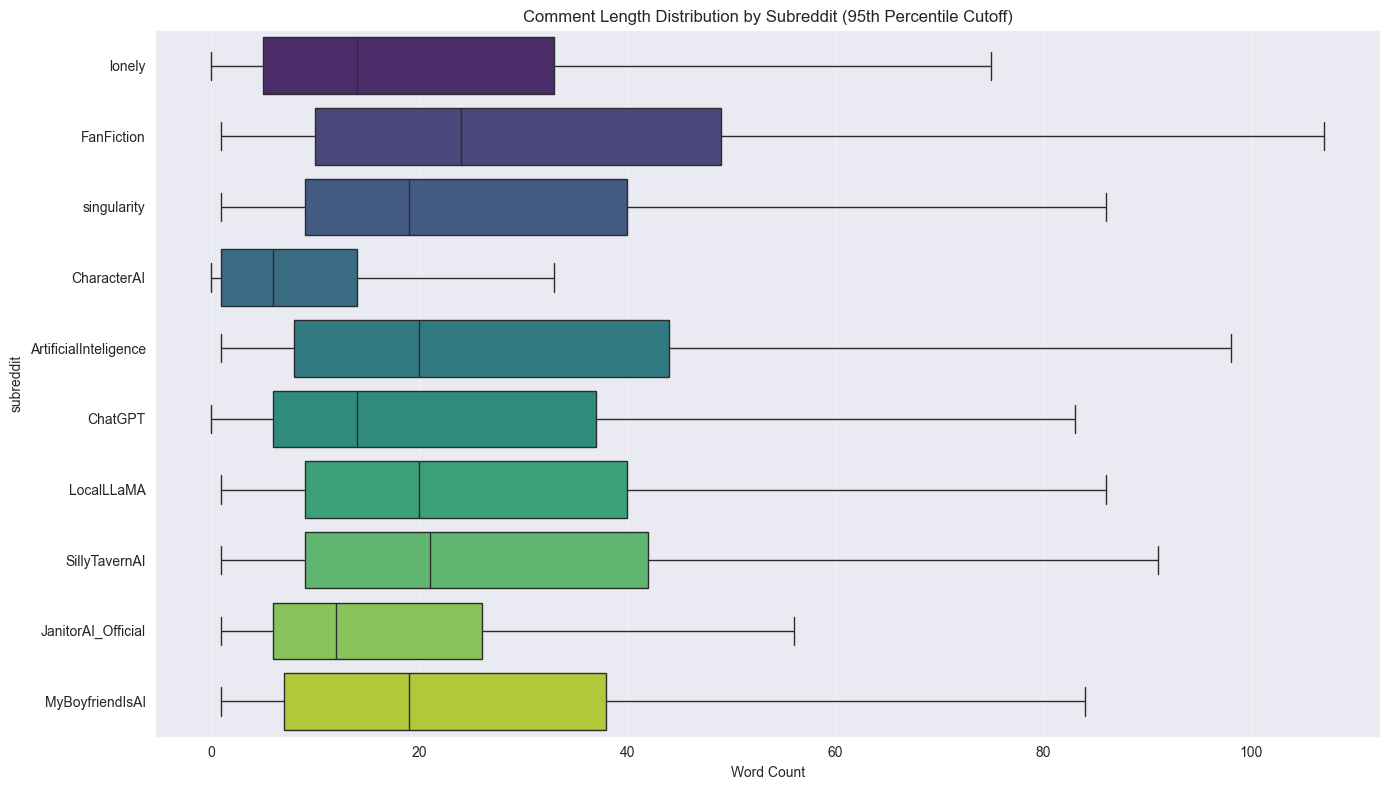

In [72]:
plot_data = comments_df[comments_df['word_count'] < comments_df['word_count'].quantile(0.95)].copy()
plt.figure(figsize=(14, 8))

# 2. Boxplot
sns.boxplot(
    data=plot_data,
    x='word_count',
    y='subreddit',
    showfliers=False, # we hide the outliers to keep it clean
    palette="viridis"
)

plt.title("Comment Length Distribution by Subreddit (95th Percentile Cutoff)")
plt.xlabel("Word Count")
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
# 4. CLEANING

In [75]:
# we exclude all bots and keep humans (active and low-activity)
VALID_AUTHOR_TYPES = [
    'Likely Human',
    'Likely Human (Low Activity)'
]

# these are the ones that contain enough English context for Word2Vec
VALID_LANG_STATUSES = [
    'english_rescue',
    'high_confidence', # we will check lang='en' separately for this
    'low_conf_en'
]

In [76]:
def apply_purge(df):
    initial_len = len(df)

    # we only want content that actually exists
    df = df[df['text_status'] == 'available'].copy()
    print(f"After status filter: {len(df)} (dropped {initial_len - len(df)})")

    # we map the author_stats to the dataframe and filer by valid author types
    allowed_authors = author_stats_df[
        author_stats_df['author_type'].isin(VALID_AUTHOR_TYPES)
    ].index

    df = df[df['author'].isin(allowed_authors)]
    print(f"After author filter: {len(df)}")

    # filtering copypasta
    df = df[df['is_copypasta'] == False]
    print(f"After copypasta filter: {len(df)}")

    # language and length filter
    mask_status_ok = df['lang_status'].isin(VALID_LANG_STATUSES)

    # for high_confidence we enforce 'en'
    # we keep rows where status is not high_confidence (passed by above) or (status is high_confidence and lang is en)
    # 'too_short' is automatically excluded because it's not in VALID_LANG_STATUSES
    mask_lang_en = (df['lang_status'] != 'high_confidence') | (df['lang'] == 'en')

    df = df[mask_status_ok & mask_lang_en]

    print(f"After language/length filter: {len(df)}")
    print(f"Total removed: {initial_len - len(df)} ({((initial_len - len(df))/initial_len)*100:.2f}%)")

    return df

In [77]:
clean_comments = apply_purge(comments_df)

After status filter: 5642738 (dropped 351014)
After author filter: 5408340
After copypasta filter: 5406920
After language/length filter: 3925232
Total removed: 2068520 (34.51%)


In [78]:
clean_submissions = apply_purge(submissions_df)

After status filter: 284223 (dropped 322673)
After author filter: 234481
After copypasta filter: 234468
After language/length filter: 200349
Total removed: 406547 (66.99%)


In [79]:
print("Final check (comments)")
print(clean_comments['subreddit'].value_counts())

Final check (comments)
subreddit
ChatGPT                  1093757
singularity               693816
CharacterAI               624592
FanFiction                593674
lonely                    341269
LocalLLaMA                249905
JanitorAI_Official        155419
ArtificialInteligence     134487
SillyTavernAI              34620
MyBoyfriendIsAI             3574
Name: count, dtype: int64


In [80]:
print("Final Check (submissions)")
print(clean_submissions['subreddit'].value_counts())

Final Check (submissions)
subreddit
CharacterAI              48358
lonely                   42564
ChatGPT                  40564
FanFiction               20481
JanitorAI_Official       18771
LocalLLaMA               11306
singularity               7548
ArtificialInteligence     7184
SillyTavernAI             3285
MyBoyfriendIsAI            288
Name: count, dtype: int64


In [90]:
clean_comments.to_parquet('clean_comments.parquet')

In [91]:
clean_submissions.to_parquet('clean_submissions.parquet')

In [83]:
# 5. WORD FILTERING

In [84]:
# 5.1. CORPUS PREPARING

In [85]:
# the semantic core subreddits are tier 1 + MyBoyfriendIsAI
TRAINING_SUBREDDITS = [
    'LocalLLaMA',
    'SillyTavernAI',
    'JanitorAI_Official',
    'CharacterAI',
    'MyBoyfriendIsAI'
]

In [86]:
def prepare_corpus(comments, submissions):
    c_core = comments[comments['subreddit'].isin(TRAINING_SUBREDDITS)]
    s_core = submissions[submissions['subreddit'].isin(TRAINING_SUBREDDITS)]

    # combine relevant text columns
    # for submissions, we combine title + selftext
    text_c = c_core['body'].astype(str).tolist()
    text_s = (s_core['title'].fillna('') + " " + s_core['selftext'].fillna('')).astype(str).tolist()

    full_corpus = text_c + text_s
    print(f"Total documents for training: {len(full_corpus)}")

    return full_corpus

In [87]:
def train_model(corpus_list):
    # basic tokenization (split by space, gensim handles basic splitting well)
    # simple_preprocess lowercases and removes punctuation
    tokenized_sentences = [gensim.utils.simple_preprocess(text) for text in corpus_list]

    # we ignore bigrams that appear less than 30 times
    phrases = Phrases(tokenized_sentences, min_count=30, threshold=10)
    bigram = Phraser(phrases)

    data_bigrams = [bigram[sent] for sent in tokenized_sentences]

    print("Training Word2Vec")
    model = Word2Vec(
        sentences=data_bigrams,
        vector_size=100, # sufficient for semantic similarity
        window=5,        # for context, looks 5 words behind and ahead
        min_count=20,    # drop rare words (typos, unique IDs)
        workers=10,
        sg=1,            # slower but usually better for semantic relationships
        epochs=10
    )

    print("Training complete")
    return model

In [88]:
training_corpus = prepare_corpus(clean_comments, clean_submissions)

Total documents for training: 1150118


In [89]:
w2v_model = train_model(training_corpus)

Training Word2Vec
Training complete


In [90]:
w2v_model.save("pushshift_ai.model")

In [91]:
# 5.2. KEYWORD HARVESTING

In [92]:
w2v_model = gensim.models.Word2Vec.load("pushshift_ai.model")

In [2]:
clean_comments = pd.read_parquet('clean_comments.parquet')
clean_submissions = pd.read_parquet('clean_submissions.parquet')

In [93]:
# sanity check
test_words = ['llama', 'jailbreak', 'girlfriend', 'nsfw', 'relationship', 'filter', 'deaddove']
for w in test_words:
    print(f"\nMost similar to '{w}':")
    print(w2v_model.wv.most_similar(w, topn=6))


Most similar to 'llama':
[('qwen', 0.8490127325057983), ('mistral', 0.8481859564781189), ('phi', 0.8281393647193909), ('mixtral', 0.8258997797966003), ('falcon', 0.8253526091575623), ('gemma', 0.8190957903862)]

Most similar to 'jailbreak':
[('jailbreak_prompt', 0.845596969127655), ('jailbreaks', 0.8403199315071106), ('jb', 0.7980794906616211), ('jail_break', 0.788895308971405), ('custom_prompt', 0.7856188416481018), ('custom_prompts', 0.776892900466919)]

Most similar to 'girlfriend':
[('boyfriend', 0.8900613188743591), ('gf', 0.8504858613014221), ('best_friend', 0.8026276230812073), ('partner', 0.7857866883277893), ('husband', 0.779077410697937), ('wife', 0.778404951095581)]

Most similar to 'nsfw':
[('sfw', 0.8615629076957703), ('nsfw_content', 0.8198754191398621), ('nfsw', 0.7616432309150696), ('lewd', 0.7383570075035095), ('nswf', 0.728767991065979), ('erp', 0.7279137372970581)]

Most similar to 'relationship':
[('relationships', 0.819149374961853), ('romantic_relationship', 0.76

In [94]:
def harvest_keywords(model, seeds_dict, top_n=50):
    expanded_lexicon = {}

    for category, seeds in seeds_dict.items():
        print(f"\nProcessing: {category}")
        cluster = set(seeds)

        for seed in seeds:
            # if seed exists in model, get similar words
            if seed in model.wv:
                similar = model.wv.most_similar(seed, topn=top_n)
                for word, score in similar:
                    # score must be decent to be relevant
                    if score > 0.5:
                        cluster.add(word)
            else:
                print(f"Seed {seed} not in vocabulary")

        expanded_lexicon[category] = sorted(list(cluster))
        print(f"  Found {len(cluster)} unique terms")

    return expanded_lexicon

In [147]:
SEEDS = {
    "INTIMACY_RELATIONSHIP": [
        "girlfriend", "boyfriend", "relationship", "intimacy",  "soulmate",
        "companion", "emotional_connection",  "waifu", "husbando"
    ],
    "TECH_MECHANICS": [
        "llama", "mistral", "gguf", "quantization", "parameter", "vram",
        "gpu", "inference", "context_window", "token", "frontend", "backend"
    ],
    "ROLEPLAY_PRACTICE": [
        "roleplay", "rp", "ooc", "persona", "custom_prompt", "lorebook",
        "world_info", "slow_burn", "angst", "fluff"
    ],
    "CENSORSHIP_NSFW": [
        "nsfw", "erp", "jailbreak", "filter", "censorship", "bypass",
        "uncensored", "lobotomized", "alignment", "refusal"
    ]
}

In [148]:
LIST_MARKERS = [
    "ai", "artificial_intelligence", "bot", "bots", "chatbot", "chatbots",
    "chatgpt", "gpt", "llm", "large_language_model", "algorithm",
    "bing", "bard", "copilot", "gemini", "claude", "llama"
]

In [149]:
lexicon = harvest_keywords(w2v_model, SEEDS)


Processing: INTIMACY_RELATIONSHIP
  Found 301 unique terms

Processing: TECH_MECHANICS
  Found 465 unique terms

Processing: ROLEPLAY_PRACTICE
  Found 316 unique terms

Processing: CENSORSHIP_NSFW
  Found 367 unique terms


In [150]:
for cat, words in lexicon.items():
    print(f"\n[{cat}] ({len(words)} words)")
    print(", ".join(words))


[INTIMACY_RELATIONSHIP] (301 words)
abusive_relationship, acquaintance, adopted_daughter, affair, affection, affirmation, aftercare, ailice, anime_waifu, arachne, archie, arranged_marriage, assistant, assistants, assitant, attraction, attuned, authenticity, ava, awkwardness, babygirls, babysitter, bbg, beloved, best_friend, bestfriend, bestie, besties, bf_gf, bfs, blorbo, body_pillow, bond, bonding, bonds, boy, boyfriend, boyfriends, breakup, bully_victim, caleb, captor, caretaker, cat_girl, celine, chaste, chatbot, chatbotgf, cheated_on, childhood_friend, childhood_friends, childhood_trauma, ciel, classmate, clive, closeness, co_pilot, cockroach, colleague, companion, companions, companionship, confidant, consensual, cousin, crowned, crush, dad, dads, dating, daughter, daughters, dean_winchester, desire, dilf, dio_brando, dissociation, dommy_mommy, doting, dungeon_master, dysmorphia, emotion, emotional, emotional_attachment, emotional_connection, emotional_depth, emotionally_charged,

In [98]:
# 5.3. TIER 2 FILTERING

We also revised the logic for filtering datasets. For Tier 2:
* The lists LIST_INTIMACY and LIST_ROLEPLAY were merged, as they conceptually overlap significantly (they represent terms used in fan fiction, fandoms, and roleplaying in the classical sense).
* The LIST_ANCHORS list was created, which includes expressions that explicitly mention the markers of the subculture being studied and cannot be applied in another context.
* The remaining lists were revised and shortened

In [36]:
TIER_2_SUBS = ['ChatGPT', 'ArtificialInteligence', 'singularity']

In [37]:
LIST_ANCHORS = [
    # services
    "janitorai", "janitor_ai",  "jai", "character.ai", "characterai", "c.ai", "cai", "chai_app", "chai",
    "sillytavern", "silly_tavern", "agnai", "risuai", "venus_chub", "chub_ai",
    "replika", "paradot", "kindroid", "nomi.ai", "ai_companion", "smoothcompanion",
    "instruct_mode", "instruct_template", 'silicon_maid', 'noromaid', 'gemmasutra', 'clewd',
    'cleverbot', 'novelai',

    # explicit relational terms
    "ai_girlfriend", "ai_boyfriend", "ai_wife", "ai_husband", "ai_partner",
    "virtual_girlfriend", "virtual_boyfriend", "virtual_waifu",
    "digital_companion", "ai_lover", "robot_girlfriend", "robot_boyfriend"
]

LIST_INTIMACY = [
    "age_gap", "anime_waifu", "bbg", "blorbo", "blorbos", "cat_girl", "catgirl", "dilf", "dommy_mommy", "dungeon_master",
    "fallen_angel", "femboy_roommate", "fictional_crush", "fictional_crushes", "fictional_men", "foreplay", "fwb", "husbando",
    "husbandos", "mafia_husband", "male_oc", "malewife", "milf", "need_futanari", "oc_anypov",
    "okkotsu", "sexting", "limerence", "tomboy", "waifu", "waifus", "lewd", "angst_fluff", "anypov", "anypov_fluff",
    "author_note", "author_notes", "authors_note", "authors_notes",  "catboy", "char_perspective",
    "character_creation", "character_sheet", "chromadb", "dead_dove", "deaddove",  "erotic_novel",
    "erotic_roleplay", "established_relationship", "fandom_wiki", "fem_pov", "femdom", "fempov",
    "fluff_angst", "heart_wrenching", "hurt_comfort",
    "lore_book", "lore_books", "lore_heavy", "lorebook", "lorebook_entries", "lorebook_entry", "lorebooks",
    "love_triangle", "lovey_dovey", "male_persona", "male_pov", "male_pronouns", "malepov",
    "noass", "non_con", "ntr", "ocs", "omegaverse",
    "ooc_commands", "oocs", "personality_section", "personaname", "personas", "petplay", "preferred_pronouns",
    "rd_person", "rp", "rp_ing", "rping", "loli", "self_insert", "sex_scene", "slashers", "therapy_session",
    "threesome", "transmasc", "wlw", "worldbook"
]

LIST_TECH = [
    "awq", "context_window", "exl2", "ggml", "gguf", "gptq", "gptq_bit", "kobold", "koboldcpp", "kv_cache",
    "layer_offloading", "localai", "lora", "lora_adapters", "mistral", "mixtral", "ooba", "oobabooga",
    "openwebui", "mistral_nemo", "textgen_webui", "top_k", "top_p", "vram_offloading"
]

LIST_CENSORSHIP = [
    "allow_nsfw", "borderline_unusable", "castrated", "catastrophic_forgetting", "dark_themes",
    "degraded", "explicit_content", "extreme_violence", "heavily_censored", "heavily_quantized",
    "inappropriate_content", "jail_break", "jailbreak", "jailbreak_prompt", "jailbreak_prompts",
    "jailbreaking", "jailbreaks", "jailbroken", "jb", "less_restrictive", "lobotomize", "lobotomized",
    "lobotomizing", "mature_content", "nsfw_content", "nsfw_filter", "nsfw_scenes", "sanitized", "sexual_content",
    "unaligned", "violent_content"
]

In [38]:
# we pass strings to workers to avoid pickle issues
def get_pattern_string(term_list):
    term_list.sort(key=len, reverse=True)
    cleaned_terms = [re.escape(t).replace(r"\_", r"[\s_-]+") for t in term_list]
    return r'\b(' + '|'.join(cleaned_terms) + r')\b'

In [39]:
PAT_ANCHORS = get_pattern_string(LIST_ANCHORS)
PAT_INTIMACY = get_pattern_string(LIST_INTIMACY)
PAT_TECH = get_pattern_string(LIST_TECH)
PAT_CENSORSHIP = get_pattern_string(LIST_CENSORSHIP)

In [40]:
def process_chunk(df_chunk):
    # compile regex
    re_int = re.compile(PAT_INTIMACY, re.IGNORECASE)
    re_tch = re.compile(PAT_TECH, re.IGNORECASE)
    re_rol = re.compile(PAT_ANCHORS, re.IGNORECASE)
    re_cen = re.compile(PAT_CENSORSHIP, re.IGNORECASE)

    # vectorized search
    bodies = df_chunk['body'].astype(str)

    is_int = bodies.str.contains(re_int, regex=True, na=False)
    is_tch = bodies.str.contains(re_tch, regex=True, na=False)
    is_rol = bodies.str.contains(re_rol, regex=True, na=False)
    is_cen = bodies.str.contains(re_cen, regex=True, na=False)

    # we filter immediately to save ram
    mask = is_int | is_tch | is_rol | is_cen

    if not mask.any():
        return pd.DataFrame(columns=list(df_chunk.columns) + ['topic_type'])

    result_df = df_chunk[mask].copy()

    # we slice the booleans to match the filtered dataframe
    m_int = is_int[mask].values
    m_tch = is_tch[mask].values
    m_rol = is_rol[mask].values
    m_cen = is_cen[mask].values

    labels = []
    for i, t, r, c in zip(m_int, m_tch, m_rol, m_cen):
        tags = []
        if i: tags.append("INTIMACY")
        if t: tags.append("TECH")
        if r: tags.append("ANCHOR")
        if c: tags.append("CENSORSHIP")
        labels.append(", ".join(tags))

    result_df['topic_type'] = labels

    result_df['is_intimacy'] = m_int
    result_df['is_tech'] = m_tch
    result_df['is_anchor'] = m_rol
    result_df['is_censorship'] = m_cen

    return result_df

In [41]:
def analyze_tier2(df, n_jobs=-1):
    t2_mask = df['subreddit'].isin(TIER_2_SUBS)
    df_t2 = df[t2_mask].copy()

    # to cover submissions
    if 'body' not in df_t2.columns and 'title' in df_t2.columns:
        df_t2['body'] = df_t2['title'].fillna('') + " " + df_t2['selftext'].fillna('')

    total_rows = len(df_t2)
    print(f"Processing {total_rows}")

    chunks = np.array_split(df_t2, 40)
    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(process_chunk)(chunk) for chunk in chunks
    )

    final_df = pd.concat(results, ignore_index=True)

    print(f"Complete, kept {len(final_df)} rows ({len(final_df)/total_rows:.2%})")
    return final_df

In [42]:
t2_comments_final = analyze_tier2(clean_comments)

Processing 1920968


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 12035 rows (0.63%)


In [10]:
t2_submissions_final = analyze_tier2(clean_submissions)

Processing 55296


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 1189 rows (2.15%)


In [139]:
def print_topic_stats(df):
    # total hits per category
    stats = {
        "INTIMACY": df['is_intimacy'].sum(),
        "TECH": df['is_tech'].sum(),
        "ANCHOR": df['is_anchor'].sum(),
        "CENSORSHIP": df['is_censorship'].sum()
    }

    stats_s = pd.Series(stats).sort_values(ascending=False)
    print("\nTotal mentions per category:")
    print(stats_s)

    # topic combinations
    print("\nTop 10 Topic Combinations:")
    print(df['topic_type'].value_counts().head(10))

In [140]:
print_topic_stats(t2_comments_final)


Total mentions per category:
CENSORSHIP    5619
INTIMACY      2621
TECH          1876
ANCHOR        1760
dtype: int64

Top 10 Topic Combinations:
topic_type
CENSORSHIP              5497
INTIMACY                2486
TECH                    1817
ANCHOR                  1629
INTIMACY, CENSORSHIP      60
INTIMACY, ANCHOR          55
ANCHOR, CENSORSHIP        40
TECH, ANCHOR              28
TECH, CENSORSHIP          14
INTIMACY, TECH            13
Name: count, dtype: int64


In [127]:
print_topic_stats(t2_submissions_final)


Total mentions per category:
CENSORSHIP    772
TECH          253
INTIMACY      215
ANCHOR        171
dtype: int64

Top 10 Topic Combinations:
topic_type
CENSORSHIP              732
TECH                    224
INTIMACY                189
ANCHOR                  154
TECH, CENSORSHIP         17
INTIMACY, CENSORSHIP     14
ANCHOR, CENSORSHIP        6
INTIMACY, TECH            4
INTIMACY, ANCHOR          3
TECH, ANCHOR              3
Name: count, dtype: int64


In [143]:
t2_comments_final[['subreddit', 'topic_type', 'body']].sample(150)

,subreddit,topic_type,body
384,ChatGPT,ANCHOR,I'm not sure of the model but this has been go...
6282,ChatGPT,CENSORSHIP,A third reason: \n\nPeople twist the AI to ext...
3798,singularity,ANCHOR,I was kidding tbh I'm just serving sarcasm for...
3365,ChatGPT,TECH,claude and mistral are qzite good. while claud...
2745,singularity,INTIMACY,lol I think the problem too is you might get a...
...,...,...,...
7719,ChatGPT,INTIMACY,As someone who has to already deal with teenag...
5394,ChatGPT,CENSORSHIP,"> This is GPT ""sanitized"" by Microsoft, to the..."
11056,singularity,INTIMACY,this one is still a catgirl you cant escape th...
11241,ChatGPT,CENSORSHIP,Downshot = “porn angle”\n\nCat = “pussy”\n\nPr...


In [142]:
t2_submissions_final[['subreddit', 'topic_type', 'body']].sample(150)

,subreddit,topic_type,body
0,ChatGPT,CENSORSHIP,Snooping around Jeffrey Epstein's computer via...
1,singularity,CENSORSHIP,Tricking Chat GPT into Outputting a Python Pro...
2,ChatGPT,CENSORSHIP,body disposal I am envious of everyone here th...
3,ChatGPT,INTIMACY,I managed to create a half-way decent RP with ...
4,ArtificialInteligence,ANCHOR,so i found a program that lets you talk to/cre...
...,...,...,...
1161,ChatGPT,INTIMACY,This filter is bs Anyone else getting tired of...
1162,ChatGPT,CENSORSHIP,Did 4o get dumber after the roll-back?? Yes th...
1163,ChatGPT,INTIMACY,I asked ChatGPT how I can make better use of i...
1164,ChatGPT,CENSORSHIP,Any way to reverse the roll back? I was one of...


In [11]:
t2_submissions_final.to_parquet('t2_submissions_final.parquet')
t2_comments_final.to_parquet('t2_comments_final.parquet')

In [79]:
# 5.4. TIER 3 FILTERING

For Tier 3, considering the significant difference in vocabulary between r/FanFiction and r/lonely:
* We identified LIST_MARKERS with generic AI terms, which was applied in combination with the LIST_ROLEPLAY list (fanfic jargon) for r/FanFiction and LIST_INTERACTION (verbs of communication) for r/lonely.
* The LIST_ANCHORS list was also updated.
* Using this logic allowed us to obtain a focused dataset with 2,226 records, compared to 50 records in the previous approach (total comments + submissions)

In [12]:
LIST_ANCHORS = [
    # services
    "janitorai", "janitor_ai",  "jai", "character.ai", "characterai", "c.ai", "cai", "chai_app",
    "sillytavern", "silly_tavern", "agnai", "risuai", "venus_chub", "chub_ai",
    "replika", "paradot", "kindroid", "nomi.ai", "ai_companion", "smoothcompanion",
    "instruct_mode", "instruct_template", 'silicon_maid', 'noromaid', 'gemmasutra', 'clewd',

    # explicit relational terms
    "ai_girlfriend", "ai_boyfriend", "ai_wife", "ai_husband", "ai_partner",
    "virtual_girlfriend", "virtual_boyfriend", "virtual_waifu",
    "digital_companion", "ai_lover", "robot_girlfriend", "robot_boyfriend",

    # technical terms (unexpected in this context)
    "awq", "context_window", "exl2", "ggml", "gguf", "gptq", "gptq_bit", "koboldcpp", "kv_cache",
    "layer_offloading", "localai", "lora", "lora_adapters", "mistral", "mixtral", "ooba", "oobabooga",
    "openwebui", "mistral_nemo", "textgen_webui", "top_k",
    "top_p", "vram_offloading"
]

LIST_MARKERS = [
    # core terms
    "ai", "artificial_intelligence", "artificial_inteligence",
    "generative_ai", "gen_ai",
    "llm", "llms", "large_language_model", "large_language_models",

    # bot terminology
    "chatbot", "chatbots", "chat_bot",
    "sexbot", "sex_bot",
    "ai_chat", "ai_generated",

    # brand names that are unlikely to be confused in non-tech contexts
    "chatgpt", "gpt", "gpt3", "gpt4", "open_ai", "openai",
    "bing_chat", "bing_ai"
]


LIST_INTERACTION = [
    # direct communication
    "talk", "talked", "talking",
    "chat", "chatted", "chatting",
    "speak", "spoke", "speaking",
    "listen", "listening",
    "reply", "replying", "respond", "responding",
    "text", "texting", "texted",
    "message", "messaging", "messaged",
    "call", "calling", "voice_chat",
    "ask", "asked", "tell", "told",
    "confess", "confessed",
    "vent", "venting",
    "socialize", "socializing",

    # emotional connection
    "connect", "connection", "connected",
    "bond", "bonding", "bonded",
    "attach", "attached", "attachment",
    "depend", "dependency", "dependent",
    "rely", "reliant",
    "comfort", "comforting", "comforted",
    "soothe", "soothing",
    "support", "supported", "supportive",
    "understand", "understands", "understanding",
    "judge", "judging", "judgment",
    "care", "cares", "caring",
    "love", "loved", "loving",

    # relational roles
    "friend", "friendship", "buddy", "pal",
    "partner", "partnership",
    "girlfriend", "boyfriend", "gf", "bf",
    "wife", "husband", "spouse",
    "waifu", "husbando",
    "lover", "companion", "companionship",
    "therapist", "therapy", "psychologist",
    "mentor", "coach",
    "date", "dating",
    "relationship", "relationships",
    "someone", "anybody", "nobody",
    "listener", "company",

    # intimacy and action
    "cuddle", "cuddling",
    "hug", "hugging",
    "kiss", "kissing",
    "flirt", "flirting",
    "sext", "sexting",
    "roleplay", "roleplaying"
]

LIST_ROLEPLAY = [
    "roleplay", "role_play", "role_playing", "role_plays", "roleplay", "roleplayer", "roleplaying", "roleplays",
    "alichat", "alternate_timeline", "anex", "angst_fluff", "anypov", "anypov_fluff", "arranged_marriage", "author_note",
    "author_notes", "authors_note", "authors_notes", "bdsm", "catboy", "char_perspective", "character_creation",
    "character_sheet", "chromadb", "dead_dove", "deaddove", "dilf", "erotic_novel", "erotic_roleplay", "erp",
    "established_relationship", "fandom_wiki", "fem_pov", "femdom", "fempov", "fluff_angst", "heart_wrenching",
    "hurt_comfort", "instruct_mode", "instruct_template", "instruction_template", "lore_book", "lore_books",
    "lore_heavy", "lorebook", "lorebook_entries", "lorebook_entry", "lorebooks", "love_triangle", "lovey_dovey",
    "male_oc", "male_persona", "male_pov", "male_pronouns", "malepov", "misgender", "multigen", "noass", "non_con",
    "nsfw_scenes", "ntr", "oc_anypov", "omegaverse", "ooc_commands", "personality_section", "personaname", "personas",
    "petplay","preferred_pronouns", "rd_person", "rp", "rp_ing", "rping", "loli", "self_insert", "sex_scene", "slashers",
    "therapy_session", "threesome", "transmasc", "wlw", "worldbook", "age_gap", "anime_waifu", "bbg", "blorbo", "blorbos",
    "body_pillow", "cat_girl", "catgirl", "cuddle", "delulu", "dilf", "dommy", "dommy_mommy", "dungeon_master",
    "fallen_angel", "femboy_roommate", "fictional_crush", "fictional_crushes", "fictional_men", "foreplay", "furry",
    "fwb", "husbando", "husbandos", "jetstream_sam", "localagi", "mafia_husband", "male_oc", "malewife", "milf",
    "need_futanari", "oc_anypov", "okkotsu", "self_awareness", "sexting", "smoothcompanion", "limerence", "tomboy", "waifu",
    "waifus", "lewd", 'brainstorm', 'brainstorming', 'co-write', 'co-writing', 'cowriter', 'generator', 'generating'
]

In [13]:
TIER_3_SUBS = ['FanFiction', 'lonely']

In [14]:
def get_pattern_string(term_list):
    term_list.sort(key=len, reverse=True)

    cleaned_terms = [re.escape(t).replace(r"\_", r"[\s_-]+") for t in term_list]
    return r'\b(' + '|'.join(cleaned_terms) + r')\b'

In [15]:
PAT_ANCHORS = get_pattern_string(LIST_ANCHORS)
PAT_MARKERS = get_pattern_string(LIST_MARKERS)
PAT_ROLEPLAY = get_pattern_string(LIST_ROLEPLAY)
PAT_INTERACTION = get_pattern_string(LIST_INTERACTION)

In [16]:
def process_chunk_tier3(df_chunk):
    re_anchor = re.compile(PAT_ANCHORS, re.IGNORECASE)
    re_marker = re.compile(PAT_MARKERS, re.IGNORECASE)
    re_roleplay = re.compile(PAT_ROLEPLAY, re.IGNORECASE)
    re_interact = re.compile(PAT_INTERACTION, re.IGNORECASE)

    bodies = df_chunk['body'].astype(str)

    is_anchor = bodies.str.contains(re_anchor, regex=True, na=False)
    is_marker = bodies.str.contains(re_marker, regex=True, na=False)
    is_rp_term = bodies.str.contains(re_roleplay, regex=True, na=False)
    is_interact = bodies.str.contains(re_interact, regex=True, na=False)


    subreddits = df_chunk['subreddit'].values

    # FanFiction + roleplay
    is_fanfic_context = (subreddits == 'FanFiction') & is_rp_term

    # lonely + interaction
    is_lonely_context = (subreddits == 'lonely') & is_interact

    mask = is_anchor | (is_marker & (is_fanfic_context | is_lonely_context))

    if not mask.any():
        cols = list(df_chunk.columns) + ['topic_type', 'match_reason']
        return pd.DataFrame(columns=cols)

    result_df = df_chunk[mask].copy()

    m_anchor = is_anchor[mask].values
    m_marker = is_marker[mask].values
    m_fanfic = is_fanfic_context[mask].values
    m_lonely = is_lonely_context[mask].values

    labels = []

    for a, m, f, l in zip(m_anchor, m_marker, m_fanfic, m_lonely):
        tags = []

        if a:
            tags.append("ANCHOR")
        if m:
            if f:
                tags.append("ROLEPLAY")
            if l:
                tags.append("INTERACTION")

        labels.append(", ".join(tags))

    result_df['topic_type'] = labels

    result_df['is_anchor'] = m_anchor
    result_df['is_roleplay'] = m_fanfic
    result_df['is_interaction'] = m_lonely

    return result_df

In [17]:
def analyze_tier3(df, n_jobs=-1):
    t3_mask = df['subreddit'].isin(TIER_3_SUBS)
    df_t3 = df[t3_mask].copy()

    # to handle submissions
    if 'body' not in df_t3.columns and 'title' in df_t3.columns:
        df_t3['body'] = df_t3['title'].fillna('') + " " + df_t3['selftext'].fillna('')

    total_rows = len(df_t3)
    print(f"Processing {total_rows} rows")

    chunks = np.array_split(df_t3, 40)

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(process_chunk_tier3)(chunk) for chunk in chunks
    )

    final_df = pd.concat(results, ignore_index=True)
    print(f"Complete, kept {len(final_df)} rows ({len(final_df)/total_rows:.2%})")

    return final_df

In [18]:
t3_comments_final = analyze_tier3(clean_comments)

Processing 935983 rows


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 1838 rows (0.20%)


In [19]:
t3_submissions_final = analyze_tier3(clean_submissions)

Processing 63045 rows


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 388 rows (0.62%)


In [20]:
t3_comments_final.to_parquet('t3_comments_final.parquet')
t3_submissions_final.to_parquet('t3_submissions_final.parquet')

In [87]:
def print_topic_stats(df):
    # total hits per category
    stats = {
        "ANCHOR": df['is_anchor'].sum(),
        "ROLEPLAY": df['is_roleplay'].sum(),
        "INTERACTION": df['is_interaction'].sum()
    }

    stats_s = pd.Series(stats).sort_values(ascending=False)
    print("\nTotal mentions per category:")
    print(stats_s)

    # topic combinations
    print("\nTop 10 Topic Combinations:")
    print(df['topic_type'].value_counts().head(10))

In [88]:
print_topic_stats(t3_comments_final)


Total mentions per category:
INTERACTION    1585
ANCHOR          236
ROLEPLAY        136
dtype: int64

Top 10 Topic Combinations:
topic_type
INTERACTION            1471
ANCHOR                  143
ROLEPLAY                131
ANCHOR, INTERACTION      89
ANCHOR, ROLEPLAY          4
Name: count, dtype: int64


In [92]:
t3_comments_final[['subreddit', 'topic_type', 'body']].sample(150)

,subreddit,topic_type,body
189,lonely,INTERACTION,It appears that Crush on AI and similar NSFW c...
1797,lonely,INTERACTION,"I like ChatGPT too, but talking to a therapist..."
768,lonely,INTERACTION,Exactly and the net/ social media/ / ‘dating ‘...
58,FanFiction,ROLEPLAY,"It's essentially a parody on a popular ship, i..."
1704,lonely,INTERACTION,Sounds stupid but [this AI gf app](http://ever...
...,...,...,...
1449,lonely,INTERACTION,You can say no human is unlovable but I've liv...
74,FanFiction,ROLEPLAY,Thanks! Brings me back to my rp days where Is ...
497,lonely,INTERACTION,My AI Girlfriend is my loving and compassionat...
1243,lonely,INTERACTION,Same. I once even sexted with a fucking AI whi...


In [186]:
t3_submissions_final[['subreddit', 'topic_type', 'body']].head(10)

,subreddit,topic_type,body
0,lonely,INTERACTION,I don't know if I just want to be alone or sta...
1,FanFiction,ROLEPLAY,Positivity and Discussion About AI Generated F...
2,FanFiction,ROLEPLAY,"Thinking a lot about GPT-3 and DALL-E ""replaci..."
3,lonely,INTERACTION,dude fucckkk I was going to best friends with ...
4,lonely,INTERACTION,I've fallen back to my old self isolation I kn...
5,lonely,INTERACTION,I was talking to the AI and it said ‘no more f...
6,lonely,"ANCHOR, INTERACTION",Got out of prison 6 months ago and all my frie...
7,FanFiction,ANCHOR,"Lost my gmail I use for fanfiction, can’t reco..."
8,FanFiction,ROLEPLAY,Persona 5 NG+ Fic in AO3 SO hiii i'm looking f...
9,lonely,INTERACTION,Lonely Bard. I was chatting with Bard (Google'...


In [130]:
# 5.5. TIER 1 FILTERING

Filtering was also performed for the LocalLLaMA community. As a subreddit where TECH vocabulary exclusively makes up the vast majority of discussions, we used extended versions of the LIST_INTIMACY and LIST_CENSORSHIP lists in combination with LIST_ANCHORS, which allowed us to focus on the more thematic aspect of this community.

In [131]:
TIER_1_SUBS = ['LocalLLaMA']

In [132]:
LIST_ANCHORS = [
    # services
    "janitorai", "janitor_ai",  "jai", "character.ai", "characterai", "c.ai", "chai_app", "chai",
    "sillytavern", "silly_tavern", "agnai", "risuai", "venus_chub", "chub_ai",
    "replika", "paradot", "kindroid", "nomi.ai", "ai_companion", "smoothcompanion",
    'silicon_maid', 'noromaid', 'gemmasutra', 'clewd', 'cleverbot', 'novelai',

    # explicit relational terms
    "ai_girlfriend", "ai_boyfriend", "ai_wife", "ai_husband", "ai_partner",
    "virtual_girlfriend", "virtual_boyfriend", "virtual_waifu",
    "digital_companion", "ai_lover", "robot_girlfriend", "robot_boyfriend"
]

LIST_INTIMACY = ['agender', 'alternate_timeline', 'anex', 'angst', 'angst_fluff', 'angsty', 'anypov', 'anypov_fluff', 'arranged_marriage', 'author_note', 'author_notes', 'authors_note', 'authors_notes', 'bdsm', 'catboy', 'char_perspective', 'character_creation', 'character_sheet', 'character_card', 'co_molekprompt', 'comedy', 'dead_dove', 'deaddove', 'discription', 'dnd', 'engage', 'epic_battle', 'erotic_novel', 'established_relationship', 'excitement_mystery', 'fandom_wiki', 'fem_pov', 'femdom', 'fempov', 'facfic', 'fic', 'facfiction', 'fight_scene', 'fight_scenes', 'fluff', 'fluff_angst', 'fluffy', 'foreplay', 'gender_neutral', 'generation_settings', 'genitalia', 'heart_wrenching', 'hurt_comfort', 'immersive', 'intro_message', 'lore_book', 'lore_books', 'lore_heavy', 'lorebook', 'lorebook_entries', 'lorebook_entry', 'lorebooks', 'love_triangle', 'lovey_dovey', 'macros', 'male_oc', 'male_persona', 'male_pov', 'male_pronouns', 'malepov', 'mlm', 'multigen', 'murder_mystery', 'narrative_style', 'noass', 'non_con', 'nsfw_scenes', 'ntr', 'oc_anypov', 'omegaverse', 'ooc', 'ooc_commands', 'oocs', 'persona', 'personality_section', 'personaname', 'personas', 'petplay', 'pfp', 'platonic', 'rd_person', 'role_play', 'role_playing', 'role_plays', 'roleplay', 'roleplayer', 'roleplaying', 'roleplays', 'rp', 'rp_ing', 'rpg', 'rping', 'rps', 'sappy', 'self_insert', 'sex_scene', 'sexual_tension', 'sfw', 'shapeshifter', 'skunk', 'slashers', 'slow_burn', 'slow_burns', 'slowburn', 'slowburns', 'take_initiative', 'threesome', 'toxic_relationship', 'trans_man', 'trans_woman', 'transmasc', 'wlw', 'world_building', 'world_info', 'worldbook', 'worldbuilding', 'worldinfo', 'zombie_apocalypse', 'storytelling', 'storywriting', 'age_gap', 'anime_waifu', 'blorbo', 'blorbos', 'body_pillow', 'bodyguard', 'cat_girl', 'catgirl', 'companion', 'companions', 'cuddle', 'dilf', 'dommy', 'dommy_mommy', 'dungeon_master', 'emotional_attachment', 'emotionally_charged', 'fallen_angel', 'father_figure', 'favorite_fictional', 'femboy_roommate', 'fictional_crush', 'fictional_crushes', 'fictional_men', 'foreplay', 'furry', 'gyaru', 'human_emotions', 'husbando', 'husbandos', 'intimate_moments', 'mafia_husband', 'male_oc', 'malewife', 'milf', 'myai', 'narrative_flow', 'need_futanari', 'neuroca', 'nihilism', 'oc_anypov', 'okkotsu', 'older_sister', 'polyamorous', 'psychosis', 'qualia', 'rapport', 'reincarnation', 'relationship_dynamics', 'self_awareness', 'sexting', 'sexual_acts', 'sexual_tension', 'slow_burn', 'snuggles', 'sugar_baby', 'tenderness', 'texture_taste', 'tomboy', 'waifu', 'waifus']

LIST_CENSORSHIP = ['allow_nsfw', 'amoral', 'author_note', 'borderline_unusable', 'brain_damaged', 'brain_dead', 'braindead', 'bypass', 'bypassed', 'bypasses', 'bypassing', 'castrated', 'catastrophic_forgetting', 'censor', 'uncensored', 'unrestrained', 'censored', 'censoring', 'censorship', 'circumvent', 'circumvented', 'circumventing', 'creative_writing', 'dark_themes', 'degraded', 'dictatorship', 'erotic_roleplay', 'erotic', 'erotica', 'erp', 'dumbed_down', 'explicit_content', 'extreme_violence', 'filters', 'gore', 'heavily_censored', 'heavily_quantized', 'horny', 'inappropriate', 'inappropriate_content', 'jail_break', 'jailbreak', 'jailbreak_prompt', 'jailbreak_prompts', 'jailbreaking', 'jailbreaks', 'jailbroken', 'explicit_sexual', 'kinky', 'less_restrictive', 'lobotomize', 'lobotomized', 'lobotomizing', 'loli', 'mature_content', 'moralist', 'moralize', 'moralizing', 'non_con', 'nsfw_content', 'nsfw_filter', 'nsfw_scenes', 'explicit_language', 'nudity', 'pedo', 'politically_correct', 'propaganda', 'puritanical', 'rejection', 'rejections', 'restriction', 'restrictions', 'restrictive', 'safeguards', 'sanitized', 'seggs', 'segs', 'sexual', 'sexual_content', 'sft', 'sfw', 'unaligned', 'underage', 'unrestricted', 'violent_content']

In [133]:
# we pass strings to workers to avoid pickle issues
def get_pattern_string(term_list):
    term_list.sort(key=len, reverse=True)
    cleaned_terms = [re.escape(t).replace(r"\_", r"[\s_-]+") for t in term_list]
    return r'\b(' + '|'.join(cleaned_terms) + r')\b'

In [134]:
PAT_ANCHORS = get_pattern_string(LIST_ANCHORS)
PAT_INTIMACY = get_pattern_string(LIST_INTIMACY)
PAT_CENSORSHIP = get_pattern_string(LIST_CENSORSHIP)

In [135]:
def process_chunk(df_chunk):
    # compile regex
    re_int = re.compile(PAT_INTIMACY, re.IGNORECASE)
    re_rol = re.compile(PAT_ANCHORS, re.IGNORECASE)
    re_cen = re.compile(PAT_CENSORSHIP, re.IGNORECASE)

    # vectorized search
    bodies = df_chunk['body'].astype(str)

    is_int = bodies.str.contains(re_int, regex=True, na=False)
    is_rol = bodies.str.contains(re_rol, regex=True, na=False)
    is_cen = bodies.str.contains(re_cen, regex=True, na=False)

    # we filter immediately to save ram
    mask = is_int | is_rol | is_cen

    if not mask.any():
        return pd.DataFrame(columns=list(df_chunk.columns) + ['topic_type'])

    result_df = df_chunk[mask].copy()

    # we slice the booleans to match the filtered dataframe
    m_int = is_int[mask].values
    m_rol = is_rol[mask].values
    m_cen = is_cen[mask].values

    labels = []
    for i, r, c in zip(m_int, m_rol, m_cen):
        tags = []
        if i: tags.append("INTIMACY")
        if r: tags.append("ANCHOR")
        if c: tags.append("CENSORSHIP")
        labels.append(", ".join(tags))

    result_df['topic_type'] = labels

    result_df['is_intimacy'] = m_int
    result_df['is_anchor'] = m_rol
    result_df['is_censorship'] = m_cen

    return result_df

In [136]:
def analyze_tier1(df, n_jobs=-1):
    t2_mask = df['subreddit'].isin(TIER_1_SUBS)
    df_t2 = df[t2_mask].copy()

    # to cover submissions
    if 'body' not in df_t2.columns and 'title' in df_t2.columns:
        df_t2['body'] = df_t2['title'].fillna('') + " " + df_t2['selftext'].fillna('')

    total_rows = len(df_t2)
    print(f"Processing {total_rows}")

    chunks = np.array_split(df_t2, 40)
    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(process_chunk)(chunk) for chunk in chunks
    )

    final_df = pd.concat(results, ignore_index=True)

    print(f"Complete, kept {len(final_df)} rows ({len(final_df)/total_rows:.2%})")
    return final_df

In [137]:
t1_comments_final = analyze_tier1(clean_comments)

Processing 249886


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 11334 rows (4.54%)


In [138]:
t1_submissions_final = analyze_tier1(clean_submissions)

Processing 11306


C:\Users\windo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Complete, kept 1149 rows (10.16%)


In [139]:
def print_topic_stats(df):
    # total hits per category
    stats = {
        "INTIMACY": df['is_intimacy'].sum(),
        "ANCHOR": df['is_anchor'].sum(),
        "CENSORSHIP": df['is_censorship'].sum()
    }

    stats_s = pd.Series(stats).sort_values(ascending=False)
    print("\nTotal mentions per category:")
    print(stats_s)

    # topic combinations
    print("\nTop 10 Topic Combinations:")
    print(df['topic_type'].value_counts().head(10))

In [140]:
print_topic_stats(t1_comments_final)


Total mentions per category:
CENSORSHIP    7247
INTIMACY      3732
ANCHOR        1466
dtype: int64

Top 10 Topic Combinations:
topic_type
CENSORSHIP                      6506
INTIMACY                        2781
ANCHOR                          1012
INTIMACY, CENSORSHIP             581
INTIMACY, ANCHOR                 294
ANCHOR, CENSORSHIP                84
INTIMACY, ANCHOR, CENSORSHIP      76
Name: count, dtype: int64


In [141]:
print_topic_stats(t1_submissions_final)


Total mentions per category:
CENSORSHIP    742
INTIMACY      464
ANCHOR        143
dtype: int64

Top 10 Topic Combinations:
topic_type
CENSORSHIP                      594
INTIMACY                        297
INTIMACY, CENSORSHIP            115
ANCHOR                           82
INTIMACY, ANCHOR                 28
INTIMACY, ANCHOR, CENSORSHIP     24
ANCHOR, CENSORSHIP                9
Name: count, dtype: int64


In [142]:
t1_comments_final[['subreddit', 'topic_type', 'body']].sample(150)

,subreddit,topic_type,body
4379,LocalLLaMA,INTIMACY,Building an animated personal waifu chatbot wi...
10065,LocalLLaMA,CENSORSHIP,It's a little bit better than gpt-4-turbo from...
6099,LocalLLaMA,"INTIMACY, CENSORSHIP",I don't think any of the current fine tunes of...
6825,LocalLLaMA,CENSORSHIP,Llama-2-13B-chat works best for instructions b...
2580,LocalLLaMA,CENSORSHIP,Work blocks OpenAI with local network filters ...
...,...,...,...
3815,LocalLLaMA,CENSORSHIP,Yes the wizardlm 7B seems like a natural next ...
7315,LocalLLaMA,INTIMACY,"Here's my top 3, including some different leve..."
8672,LocalLLaMA,ANCHOR,I recommend exl2 models together with https://...
6047,LocalLLaMA,"INTIMACY, ANCHOR",- Use [SillyTavern](https://github.com/SillyTa...


In [143]:
t1_submissions_final[['subreddit', 'title', 'selftext']].sample(150)

,subreddit,title,selftext
1108,LocalLLaMA,What are your favorite models for professional...,Looking for some decent 8b or 14b models for p...
693,LocalLLaMA,How to run (or convert) PyTorch model with lla...,I recently can get a model running in the loca...
490,LocalLLaMA,How to check LLM requirements and GPU specific...,I have played around with language models in G...
364,LocalLLaMA,I think all models using the Vicuna 1.1 prompt...,>A chat between a curious user and an artifici...
586,LocalLLaMA,Anyone know how I can use llama 2 to do roleplay?,Well I see at 4chan people doing roleplay with...
...,...,...,...
830,LocalLLaMA,(NEWBIE ALERT) What free GPT4ALL AI is user-fr...,**(NEW USER ALERT)**\n\n&#x200B;\n\nWhich user...
626,LocalLLaMA,I asked a simple riddle to 30+ models,I always found numbers-based benchmarks somewh...
91,LocalLLaMA,NemoReRemix-12B,Improved NemoRemix by adding new Tess model. I...
640,LocalLLaMA,Let my character remember the conversation,My progress since last week has been towards c...


In [ ]:
t1_submissions_final.to_parquet('t1_submissions_final.parquet')
t1_comments_final.to_parquet('t1_comments_final.parquet')